In [2]:
from solver_selection_thm.thm_physics import ModelTHM, initialize, run, params
from solver_selection_thm.selector import SolverSelector
from solver_selection_thm.solver_space import CategoricalChoices, NumericalChoices
from solver_selection_thm.performance_predictor import (
    PerformancePredictorPassiveAgressive,
    PerformancePredictorEpsGreedy,
    RewardEstimator,
)
from solver_selection_thm.solver_space import SolverSpace
from solver_selection_thm.pp_binding import (
    KNOWN_SOLVER_COMPONENTS_THM,
    SolverSelectionMixinTHM,
)
from thm_runscript import make_solver_space_scheme_fthm
import numpy as np
from matplotlib import pyplot as plt
from load_experiments_data import load_experiments_data_thm

/home/porepy/porepy/src/porepy/utils/ui_and_logging.py:45: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import trange as progressbar_class  # type: ignore


In [75]:
import pickle
from itertools import count
from copy import copy


RUNS = ['0','1','2','8','9']
RUNS = [20, 21, 22, 23, 24]
RUNS_RANDOM = ['8','9']
# RUNS = [20,21,22]

sim_data, perf_data, solver_selector = load_experiments_data_thm(runs=RUNS, random_selection=False)
sim_data_random, perf_data_random, solver_selector = load_experiments_data_thm(runs=RUNS_RANDOM, random_selection=True)

Num solvers: 448
Num solvers: 448
Num solvers: 448
Num solvers: 448
Num solvers: 448
failed to load run_24_fthm_xinj=0.0_yinj=0.5_zinj=0.5_xprod=0.52_yprod=0.5_zprod=0.5
failed to load run_24_fthm_xinj=0.0_yinj=0.5_zinj=0.5_xprod=0.7_yprod=1.0_zprod=0.5
failed to load run_24_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=0.7_yprod=0.5_zprod=0.5
failed to load run_24_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=1.0_yprod=0.5_zprod=0.5
failed to load run_24_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=0.7_yprod=0.0_zprod=0.5
failed to load run_24_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=0.52_yprod=0.5_zprod=0.5
failed to load run_24_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=0.7_yprod=1.0_zprod=0.5
Num solvers: 448
Num solvers: 448
failed to load RANDOM_run_9_fthm_xinj=0.0_yinj=0.5_zinj=0.5_xprod=0.52_yprod=0.5_zprod=0.5
failed to load RANDOM_run_9_fthm_xinj=0.0_yinj=0.5_zinj=0.5_xprod=0.7_yprod=1.0_zprod=0.5
failed to load RANDOM_run_9_fthm_xinj=0.48_yinj=0.5_zinj=0.5_xprod=0.7_yprod=0.5_zprod=0.5
failed to load

In [17]:
from collections import defaultdict
import pandas as pd


def make_pandas(sim_data, perf_data, seq_ids):
    sim_data_dict = defaultdict(lambda: [])
    perf_data_dict = defaultdict(lambda: [])
    for seq_id, data_simulations, solver_selection_history_seq in zip(
        seq_ids, sim_data, perf_data
    ):
        sim_idx = -1
        for data_row in data_simulations:
            for data in data_row:
                sim_idx += 1

                for ts_idx, ts in enumerate(data):
                    for ls_idx, ls in enumerate(ts.linear_solves):
                        sim_data_dict["seq_id"].append(seq_id)
                        sim_data_dict["sim_idx"].append(sim_idx)
                        sim_data_dict["ts_idx"].append(ts_idx)
                        sim_data_dict["ls_idx"].append(ls_idx)
                        sim_data_dict["real_solve_time"].append(ls.linear_solve_time)
                        sim_data_dict["krylov_iters"].append(ls.krylov_iters)
                        sim_data_dict["petsc_converged_reason"].append(
                            ls.petsc_converged_reason
                        )
                        sim_data_dict["cfl"].append(ls.cfl)

        solver_selection_history = None
        for x in solver_selection_history_seq:
            if x is not None:
                solver_selection_history = x
        for reward_idx in range(len(solver_selection_history.reward)):
            perf_data_dict["seq_id"].append(seq_id)
            perf_data_dict["sim_idx"].append(sim_idx)
            perf_data_dict["reward"].append(
                solver_selection_history.reward[reward_idx]
            )
            perf_data_dict["expectation"].append(
                solver_selection_history.expectation[reward_idx]
            )
            perf_data_dict["decision_idx"].append(
                solver_selection_history.decision_idx[reward_idx]
            )
            perf_data_dict["features"].append(
                solver_selection_history.features[reward_idx]
            )
    return pd.DataFrame(data=sim_data_dict), pd.DataFrame(data=perf_data_dict)


ALL_RUNS = [str(x) for x in RUNS] + [f"R{x}" for x in RUNS_RANDOM]

df_sim, df_perf = make_pandas(
    sim_data=sim_data + sim_data_random,
    perf_data=perf_data + perf_data_random,
    seq_ids=ALL_RUNS,
)
df_sim

,seq_id,sim_idx,ts_idx,ls_idx,real_solve_time,krylov_iters,petsc_converged_reason,cfl
0,20,0,0,0,5.660293,44,2,2.759354e-16
1,20,0,0,1,4.974073,64,2,5.925187e-03
2,20,0,0,2,4.781746,68,2,5.928433e-03
3,20,0,0,3,4.537036,38,2,5.928433e-03
4,20,0,1,0,5.663898,93,2,5.928433e-03
...,...,...,...,...,...,...,...,...
24891,R9,18,40,2,-1.000000,39,2,1.755438e+00
24892,R9,18,41,0,-1.000000,44,2,2.282069e+00
24893,R9,18,41,1,-1.000000,77,2,2.282068e+00
24894,R9,18,41,2,-1.000000,64,2,2.282068e+00


Text(0.5, 0, '# Linear solve')

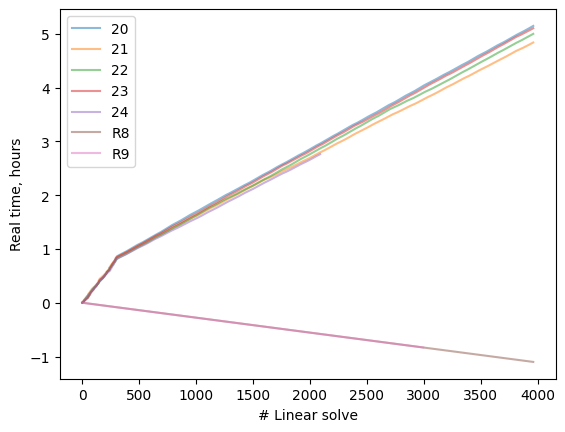

In [18]:
FAIL_REWARD = -100
HOUR = 60 * 60
DAY = 24 * HOUR

for seq_id in ALL_RUNS:
    seq_idx = np.array(df_sim.seq_id == seq_id)
    time = np.array(df_sim.real_solve_time)[seq_idx]
    plt.plot(np.cumsum(time) / HOUR, label=seq_id, alpha=0.5)
plt.legend()
plt.ylabel('Real time, hours')
plt.xlabel('# Linear solve')

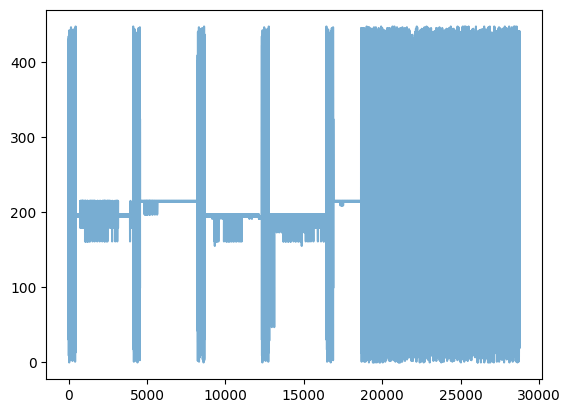

In [19]:
decision_id = np.array(df_perf.decision_idx)
_ = plt.plot(decision_id, label='Decision idx', alpha=0.6)

The number of successful solves is 3962, both for real and random.
This is because Random fails more, but proceeds only after success. And it needs to solve exactly this number of linear systems.

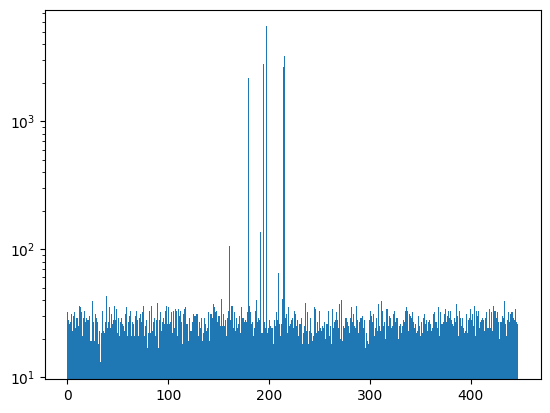

In [ ]:
num_solvers = solver_selector.solver_space.all_decisions_encoding.shape[0]
_ = plt.hist(decision_id, bins=num_solvers, log=True)

In [21]:
FAIL_REWARD = -100
num_success = (df_perf.reward > FAIL_REWARD).sum()
print(num_success, df_perf.shape[0])
print(num_success / df_perf.shape[0])

24756 28762
0.8607190042417078


* Classifier - test on a SINGLE sequence. Random and simulation.
* Oracle - Use all data.
* Regressor cv on all data

In [22]:
X = np.stack(df_perf.features)
y = np.array(df_perf.reward)
success = y > FAIL_REWARD
Xsuccess = X[success]
ysuccess = y[success]
ycat = success
print(Xsuccess.shape, ysuccess.shape)

(24756, 35) (24756,)


In [35]:
from typing import Literal

classification_case: Literal["all", "one_seq", "random"] = "one_seq"
if classification_case == "all":
    X_classification = X
    y_classification = ycat
elif classification_case == "one_seq":
    filter_ = np.array((df_perf.seq_id == "22"))
    X_classification = X[filter_]
    y_classification = ycat[filter_]
elif classification_case == "random":
    filter_ = np.array((df_perf.seq_id == "R8"))
    X_classification = X[filter_]
    y_classification = ycat[filter_]
else:
    raise ValueError(classification_case)

print(f"{classification_case = }", X_classification.shape, y_classification.shape)
print('success %:', y_classification.sum() / y_classification.size * 100)

classification_case = 'one_seq' (4107, 35) (4107,)
success %: 96.46944241538836


In [26]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import SGDClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.class_weight import compute_class_weight
from solver_selection_thm.performance_predictor import SuccessClassifier


classifier = SuccessClassifier()

scoring = ("accuracy", "f1")
cv_results = cross_validate(
    classifier,
    X_classification,
    y_classification,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=True,
    return_estimator=True,
)
for score in scoring:
    print(score)
    print("Train scores:", cv_results[f"train_{score}"])
    print("Test scores:", cv_results[f"test_{score}"])
    print("Mean Train:", np.mean(cv_results[f"train_{score}"]))
    print("Mean Test:", np.mean(cv_results[f"test_{score}"]))
    print()

best_classifier_offline = cv_results["estimator"][np.argmax(cv_results["test_f1"])]
best_classifier_offline

accuracy
Train scores: [0.94019731 0.940545   0.94467623 0.94393742 0.94706649]
Test scores: [0.94368156 0.93985747 0.93932545 0.93932545 0.94975661]
Mean Train: 0.9432844914586547
Mean Test: 0.9423893067099055

f1
Train scores: [0.96417786 0.96433227 0.96689637 0.96651612 0.96846194]
Test scores: [0.96631316 0.96394331 0.96365719 0.96365719 0.97007352]
Mean Train: 0.9660769124617344
Mean Test: 0.9655288750504762



SuccessClassifier()

2. Training offline model with cross-validation and comparing its

In [12]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold

def make_oracle_regressor():
    return GradientBoostingRegressor(random_state=42)
oracle = make_oracle_regressor()

scoring = ("r2", "neg_mean_absolute_error", "neg_mean_squared_error")
cv_results = cross_validate(
    oracle,
    Xsuccess.clip(-1e10, 1e10),
    ysuccess,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=True,
    return_estimator=True,
    n_jobs=-1,
)

In [13]:
for score in scoring:
    print(score)
    print("Train scores:", cv_results[f"train_{score}"])
    print("Test scores:", cv_results[f"test_{score}"])
    print("Mean Train:", np.mean(cv_results[f"train_{score}"]))
    print("Mean Test:", np.mean(cv_results[f"test_{score}"]))
    print()

best_regressor_offline = cv_results["estimator"][np.argmax(cv_results["test_r2"])]
best_regressor_offline

r2
Train scores: [0.87019941 0.8684621  0.86509395 0.85811077 0.87156623]
Test scores: [0.84743572 0.8554175  0.86663194 0.87715886 0.84897238]
Mean Train: 0.8666864892948686
Mean Test: 0.8591232786407194

neg_mean_absolute_error
Train scores: [-0.05854537 -0.05901374 -0.05893317 -0.05906205 -0.05857507]
Test scores: [-0.06050987 -0.05782478 -0.05939084 -0.06072644 -0.06000456]
Mean Train: -0.058825877460073304
Mean Test: -0.059691299883628354

neg_mean_squared_error
Train scores: [-0.00574853 -0.00582271 -0.00583307 -0.00589124 -0.00568195]
Test scores: [-0.00616411 -0.00585366 -0.0059472  -0.00632159 -0.00613043]
Mean Train: -0.0057954999991936635
Mean Test: -0.006083397171878933



,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [22]:
np.std(ysuccess)

0.20710260247275974

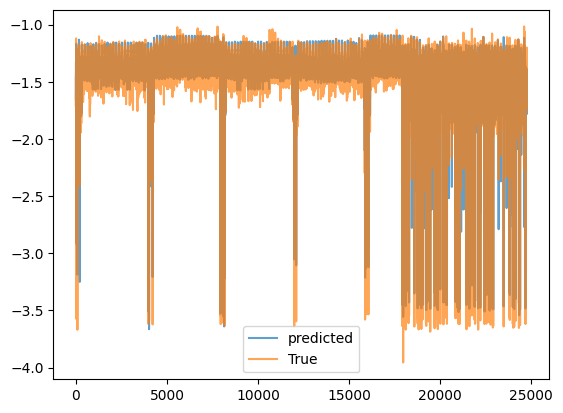

In [27]:
plt.plot(best_regressor_offline.predict(Xsuccess.clip(-1e10, 1e10)), label='predicted', alpha=0.7)
plt.plot(ysuccess, label='True', alpha=0.7)
plt.legend()

Offline ranking score

In [28]:
from typing import Literal
ranking_case: Literal["all", 'one_seq', 'random'] = 'one_seq'
if ranking_case == 'all':
    X_ranking = Xsuccess
    y_ranking = ysuccess
elif ranking_case == 'one_seq':
    filter_ = np.array((df_perf.seq_id == "22") & (df_perf.reward > FAIL_REWARD))
    X_ranking = X[filter_]
    y_ranking = y[filter_]
elif ranking_case == 'random':
    filter_ = np.array((df_perf.seq_id == "R8") & (df_perf.reward > FAIL_REWARD))
    X_ranking = X[filter_]
    y_ranking = y[filter_]
else:
    raise ValueError(ranking_case)

print(f'{ranking_case = }', X_ranking.shape, y_ranking.shape)

ranking_case = 'one_seq' (3962, 35) (3962,)


In [29]:
from sklearn.model_selection import KFold
from solver_selection_thm.performance_predictor import RewardRegressor
from tqdm import tqdm

def stack_features_solvers(features: np.ndarray, solvers: np.ndarray) -> np.ndarray:
    dim0 = solvers.shape[0]
    dim1 = features.shape[0]
    features = np.broadcast_to(features, (dim0, dim1))
    return np.concatenate([features, solvers], axis=1)

oracle = make_oracle_regressor()
oracle.fit(Xsuccess.clip(-1e10, 1e10), ysuccess)  # oracle trains on full data anyway

kf = KFold(n_splits=5, shuffle=True, random_state=42)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xranking_features = X_ranking[:, : -all_solvers.shape[1]]  # removing solvers encoding

data_k_fold = []

for train_set, test_set in kf.split(X_ranking):
    estimator = RewardRegressor()
    estimator.fit(X_ranking[train_set], ysuccess[train_set])

    data_this = []
    data_k_fold.append(data_this)

    # ranking
    for test_idx in tqdm(test_set):
        x_to_predict = stack_features_solvers(Xranking_features[test_idx], all_solvers)

        # online
        ypred = estimator.predict(x_to_predict)

        # offline
        yoracle = oracle.predict(x_to_predict.clip(-1e10, 1e10))

        data_this.append({'yoracle': yoracle, 'ypred': ypred})

100%|██████████| 792/792 [00:00<00:00, 1479.50it/s]


In [30]:
def top_1_normalized_score(ypred, ytrue):
    i = np.argmax(ypred)
    s = ytrue[i]
    ymin, ymax = np.min(ytrue), np.max(ytrue)
    if ymax == ymin:
        return 0.0  # degenerate case: all ytrue values are equal
    else:
        return -1.0 + 2.0 * (s - ymin) / (ymax - ymin)
    
def top_eps_accuracy(ypred, ytrue, eps=1e-3):
    i = np.argmax(ypred)
    return abs(ytrue[i] - np.max(ytrue)) <= eps

In [31]:
mean_NTS = [np.mean([top_1_normalized_score(ypred=x['ypred'], ytrue=x['yoracle']) for x in data_test]) for data_test in data_k_fold]
print(mean_NTS)
np.mean(mean_NTS)

[0.893266019134829, 0.9229699026427229, 0.8941288790808054, 0.8948353417430763, 0.8937031830460168]


0.8997806651294902

In [32]:
eps = 1e-1
mean_topeps = [np.mean([top_eps_accuracy(ypred=x['ypred'], ytrue=x['yoracle'], eps=eps) for x in data_test]) for data_test in data_k_fold]
print(mean_topeps)
print(np.mean(mean_topeps))

[0.9987389659520807, 1.0, 0.9987373737373737, 1.0, 0.9987373737373737]
0.9992427426853656


Incremental learning

In [33]:
class TwoEstimators:

    def __init__(self, classifier, regressor):
        self.classifier = classifier
        self.regressor = regressor

    def fit(self, X, y):
        success = y >= FAIL_REWARD
        self.classifier.fit(X, success)
        self.regressor.fit(X[success], y[success])

    def partial_fit(self, X, y):
        X = np.array(X).reshape(1, -1)
        y = np.atleast_1d(y)
        success = y >= FAIL_REWARD
        self.classifier.partial_fit(X, success)
        if success:
            self.regressor.partial_fit(X[success], y[success])

    def predict(self, X):
        reward_estimate = np.full(X.shape[0], FAIL_REWARD, dtype=float)
        success_estimate = self.classifier.predict(X)
        if not np.any(success_estimate):
            return reward_estimate

        reward_estimate[success_estimate] = self.regressor.predict(X[success_estimate])
        return reward_estimate

In [49]:
from typing import Literal
incremental_case: Literal["all", 'one_seq', 'random'] = 'one_seq'
expectations = None
if incremental_case == 'all':
    Xincr = X
    yincr = y
elif incremental_case == 'one_seq':
    filter_ = np.array((df_perf.seq_id == "22"))
    Xincr = X[filter_]
    yincr = y[filter_]
    expectations = np.array(df_perf.expectation)[filter_][num_solvers:]
elif incremental_case == 'random':
    filter_ = np.array((df_perf.seq_id == "R8"))
    Xincr = X[filter_]
    yincr = y[filter_]
else:
    raise ValueError(incremental_case)

Xoffline = Xincr[:num_solvers]
yoffline = yincr[:num_solvers]
Xonline = Xincr[num_solvers:]
yonline = yincr[num_solvers:]

print(f'{incremental_case = }', Xincr.shape, Xoffline.shape, Xonline.shape)

incremental_case = 'one_seq' (4107, 35) (448, 35) (3659, 35)


Sanity check -- the predictor here does exactly the same result on the same data as in the real sim.

In [39]:
if expectations is not None:
    regressor_online = TwoEstimators(classifier=SuccessClassifier(), regressor=RewardRegressor())
    regressor_online.fit(Xoffline, yoffline)

    reward_expected = []

    for Xbatch, ybatch in zip(tqdm(Xonline), yonline):
        # online
        ypred_expected = regressor_online.predict(Xbatch.reshape(1, -1))

        # feedback
        solve_time = np.exp(-ybatch)
        regressor_online.partial_fit(Xbatch.reshape(1, -1), [ybatch])

        # saving stats
        reward_expected.append(ypred_expected.item())

    assert np.allclose(reward_expected, expectations, rtol=1e-10, atol=1e-10)

100%|██████████| 3659/3659 [00:07<00:00, 493.27it/s]


In [40]:
from time import time

oracle = TwoEstimators(
    classifier=SuccessClassifier(), regressor=make_oracle_regressor()
)
oracle.fit(X.clip(-1e10, 1e10), y)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xonline_features = Xonline[:, : -all_solvers.shape[1]]  # removing solvers encoding

regressor_online = TwoEstimators(
    classifier=SuccessClassifier(), regressor=RewardRegressor()
)
regressor_online.fit(Xoffline, yoffline)

data_incremental = []

for Xfeature in tqdm(Xonline_features):
    x_to_predict = stack_features_solvers(Xfeature, all_solvers)

    # online
    tpred = time()
    predictions_online = regressor_online.predict(x_to_predict)
    max_score_idx_online = np.argmax(predictions_online)
    tpred = time() - tpred

    # offline
    predictions_offline = best_regressor_offline.predict(x_to_predict.clip(-1e10, 1e10))

    # feedback
    X_feedback = x_to_predict[max_score_idx_online].reshape(1, -1)
    y_feedback = predictions_offline[max_score_idx_online]
    tfeedback = time()
    regressor_online.partial_fit(X_feedback, [y_feedback])
    tfeedback = time() - tfeedback

    # saving stats
    data_incremental.append(
        {
            "ypred": predictions_online,
            "yoracle": predictions_offline,
            "tpred": tpred,
            "tfeedback": tfeedback,
        }
    )

100%|██████████| 3659/3659 [00:09<00:00, 382.15it/s]


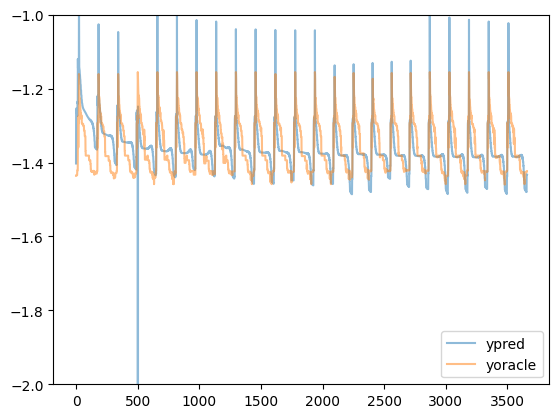

In [42]:
plt.plot([max(x["ypred"]) for x in data_incremental], label="ypred", alpha=0.5)
plt.plot([max(x["yoracle"]) for x in data_incremental], label="yoracle", alpha=0.5)
plt.ylim(-2, -1)
plt.legend()

7.70


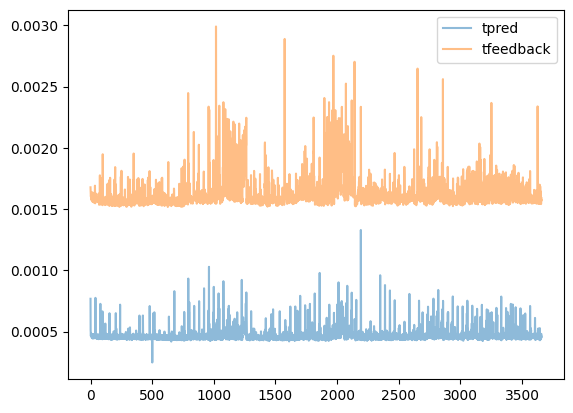

In [52]:
tpred = np.array([(x["tpred"]) for x in data_incremental])
tfeedback = np.array([(x["tfeedback"]) for x in data_incremental])
plt.plot(tpred, label="tpred", alpha=0.5)
plt.plot(tfeedback, label="tfeedback", alpha=0.5)
plt.legend()
print(f'{np.sum(tpred) + np.sum(tfeedback):.2f}')

$R = -\log(T)$

$T = \exp(-R)$

In [59]:
yoracle = np.array([max(x["yoracle"]) for x in data_incremental])
sim_time_oracle = np.sum(np.exp(-yoracle))
print(f'{sim_time_oracle / HOUR:.2f}')

3.97


In [67]:
ypred = np.array([x['yoracle'][np.argmax(x["ypred"])] for x in data_incremental])
sim_time_oracle = np.sum(np.exp(-ypred))
print(f'{sim_time_oracle / HOUR:.2f}')
# plt.plot(np.exp(-ypred))

4.23


0.88


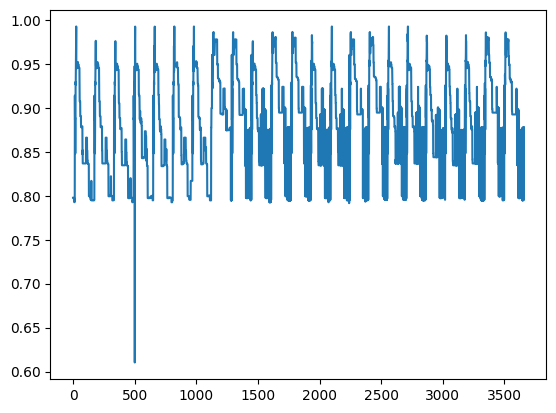

In [71]:
ntf = [top_1_normalized_score(ypred=x['ypred'], ytrue=x['yoracle']) for x in data_incremental]
plt.plot(ntf)
mean_NTS = np.mean(ntf)
print(f'{mean_NTS:.2f}')

eps = 1e-02, mean_topeps = 0.01
eps = 2e-02, mean_topeps = 0.07
eps = 5e-02, mean_topeps = 0.32
eps = 1e-01, mean_topeps = 0.83
eps = 2e-01, mean_topeps = 1.00


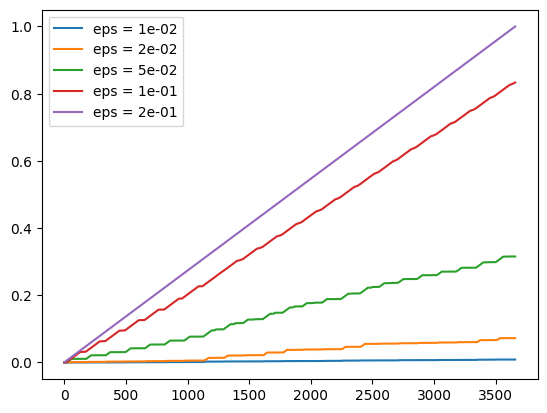

In [72]:
for eps in [1e-2, 2e-2, 5e-2, 1e-1, 2e-1]:
    topeps = [top_eps_accuracy(ypred=x['ypred'], ytrue=x['yoracle'], eps=eps) for x in data_incremental]
    plt.plot(np.cumsum(topeps) / len(topeps), label=f'{eps = :.0e}')
    mean_topeps = np.mean(topeps)
    print(f'{eps = :.0e}, {mean_topeps = :.2f}')
plt.legend()
# plt.grid()

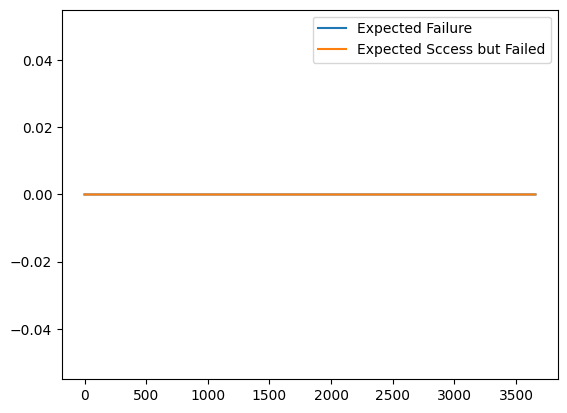

In [46]:
ef = [max(x["yoracle"]) <= FAIL_REWARD for x in data_incremental]
esbf = [
    max(x["yoracle"]) > FAIL_REWARD
    and x["yoracle"][np.argmax(x["ypred"])] <= FAIL_REWARD
    for x in data_incremental
]
plt.plot(ef, label='Expected Failure')
plt.plot(esbf, label='Expected Sccess but Failed')
plt.legend()

Regret: 225.94210223971712


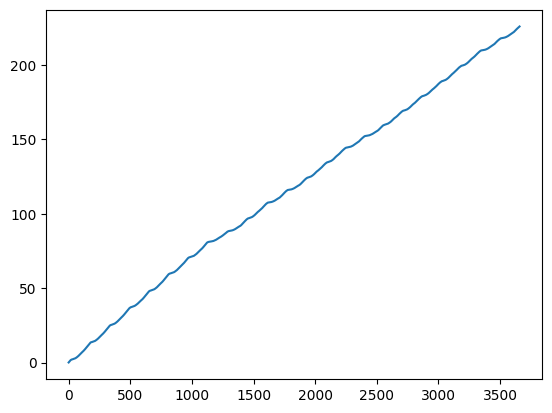

In [47]:
regret = [max(x['yoracle']) - x["yoracle"][np.argmax(x["ypred"])] for x in data_incremental]
plt.plot(np.cumsum(regret))
print('Regret:', np.sum(regret))

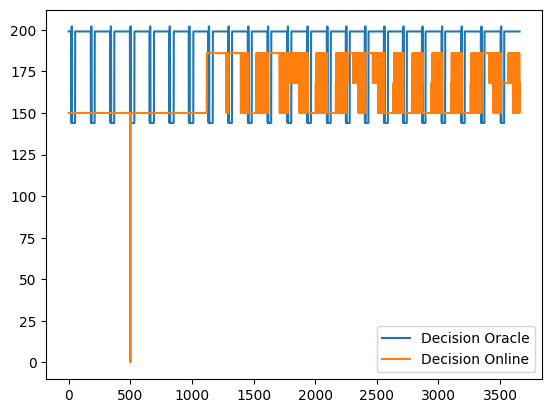

In [48]:
plt.plot([np.argmax(x['yoracle']) for x in data_incremental], label='Decision Oracle')
plt.plot([np.argmax(x['ypred']) for x in data_incremental], label='Decision Online')
plt.legend()